In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import xgboost
from xgboost import plot_tree, to_graphviz
import holidays as hdays


df = pd.read_excel('caffe_change.xlsx')

In [124]:
holidays = hdays.IN()
df['Is_holiday'] = df['Date'].apply(lambda x: 1 if x in holidays else 0)


In [130]:
weekly = (df.groupby(["Week number"])
            .agg({
                "Quantity": "sum",
                "Total": "sum",
                "Is_holiday": "max",
            })
            .reset_index()
            .rename(columns={"Quantity": "Total_Units", "Total": "Total_Sales"})
)

weekly.sort_values(by=["Week number"], inplace=True)

# categories = weekly["Category"].unique()
# category_dict = {}
# for x in range(len(categories)):
#     category_dict[categories[x]] = x

# weekly["Category"] = weekly["Category"].map(category_dict)


weekly["Lag_1_Units"] = weekly["Total_Units"].shift(1)
weekly["Lag_2_Units"] = weekly["Total_Units"].shift(2)
weekly["Lag_3_Units"] = weekly["Total_Units"].shift(3)

weekly = weekly.fillna(weekly.mean())

weekly.head()

,Week number,Total_Units,Total_Sales,Is_holiday,Lag_1_Units,Lag_2_Units,Lag_3_Units
0,1,3823,761495.32,0,3192.058824,3173.52,3159.102041
1,2,3178,688168.49,0,3823.000000,3173.52,3159.102041
2,3,2987,603048.63,0,3178.000000,3823.00,3159.102041
3,4,3567,755801.67,1,2987.000000,3178.00,3823.000000
4,5,3475,712279.10,0,3567.000000,2987.00,3178.000000


In [126]:
# X_data, Y_data = np.array(weekly.drop(columns=["Total_Units"])), np.array(weekly["Total_Units"].values)
X_data, Y_data = weekly.drop(columns="Total_Units"), weekly["Total_Units"]

In [127]:
x_train, x_test = X_data[:30], X_data[30:]
y_train, y_test = Y_data[:30], Y_data[30:]

# scaler_X = MinMaxScaler()
# x_train = scaler_X.fit_transform(x_train)
# x_test = scaler_X.transform(x_test)

# scaler_y = MinMaxScaler()
# y_train = scaler_y.fit_transform(y_train.reshape(-1, 1))
# y_test = scaler_y.transform(y_test.reshape(-1, 1))

XGBoost Model Performance:
R^2 Score: 0.8138753771781921
Mean Absolute Error: 132.11253356933594
Mean Squared Error: 31376.42578125

Feature Names:
f0 = Week number
f1 = Total_Sales
f2 = Is_holiday
f3 = Lag_1_Units
f4 = Lag_2_Units
f5 = Lag_3_Units
{'Week number': 475.0, 'Total_Sales': 362.0, 'Is_holiday': 42.0, 'Lag_1_Units': 125.0, 'Lag_2_Units': 72.0, 'Lag_3_Units': 75.0}


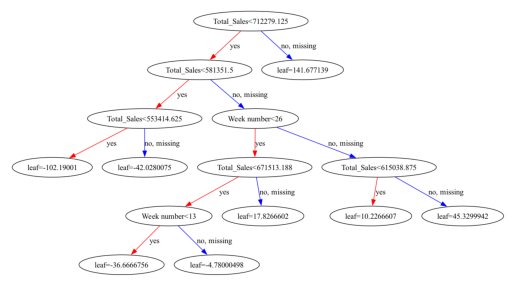

In [128]:
xgb = xgboost.XGBRegressor(max_depth=28, n_estimators=150)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)

print("XGBoost Model Performance:")
print("R^2 Score:", r2_score(y_test, y_pred_xgb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_xgb))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_xgb))

feature_names = weekly.drop(columns=["Total_Units"]).columns
print("\nFeature Names:")
for i, n in enumerate(feature_names):
    print(f"f{i} = {n}")


# booster = xgb.get_booster()
# n_trees = len(booster.get_dump())

# for i in range(n_trees):
#     plot_tree(xgb, num_trees=i)
#     plt.show()

print(xgb.get_booster().get_score())


plot_tree(xgb)
plt.show()

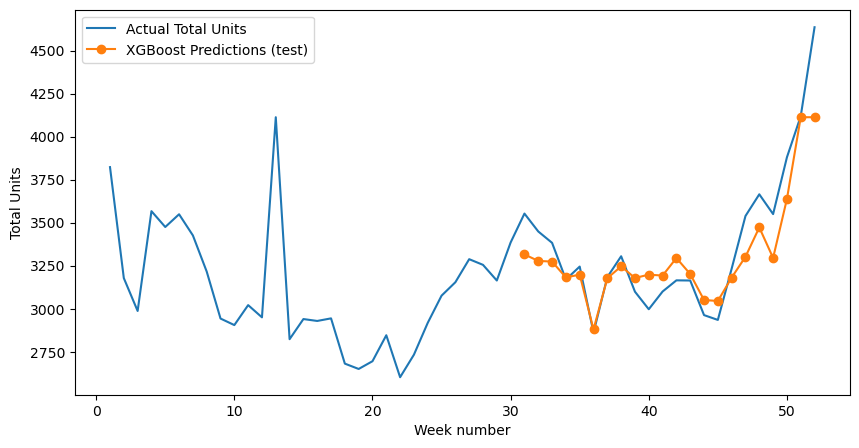

In [136]:
import matplotlib.pyplot as plt
# No scaling is used, so use predictions and test data directly
y_pred_inv = y_pred_xgb
week_nums_test = x_test["Week number"].values

# sort by week number so the line looks correct over time
order = week_nums_test.argsort()
week_nums_test_sorted = week_nums_test[order]
y_pred_inv_sorted = y_pred_inv[order]

plt.figure(figsize=(10, 5))
plt.plot(weekly["Week number"], weekly["Total_Units"], label="Actual Total Units")
plt.plot(week_nums_test_sorted, y_pred_inv_sorted, "o-", label="XGBoost Predictions (test)")
plt.xlabel("Week number")
plt.ylabel("Total Units")
plt.legend()
# plt.title("XGBoost Model Predictions vs Actual Total Units")
# plt.grid(True, alpha=0.3)
# plt.xlim(30, 52)
plt.show()
